# Coarse Graining
This tutorial introduces coarse grianing, a technique that dramatically reduces the number of qubits required for QeMCMC to be effective. The idea was first introduced in  Quantum-enhanced Markov chain Monte Carlo for systems larger than a quantum computer, https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.7.013231

In [1]:

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
import itertools

# Internal imports from our QeMCMC package
from qemcmc.sampler import ClassicalProposal, QeProposal
from qemcmc.sampler.runners import MCMCRunner
from qemcmc.utils import plot_chains, get_random_state
from qemcmc.model import EnergyModel, ModelMaker

In [2]:

# Define a larger system
n = 12
reps = 5
temp =0.1

# Initialise a ranodm Ising model problem
model = ModelMaker(n, "Fully Connected Ising", "model").model

# Initialise a MCMCM runner
runner = MCMCRunner(model, temp,)


# Run quantum chains
Using n/2 and n/4 qubits

In [3]:
gamma = (0.3, 0.6)  # Relative strength of mixer hamiltonian
time = (1, 20)  # Time for hamiltonian simulation
steps = 100

# Function to run QeMCMC for a given repetition and m value, to be used in parallel execution.
def run_qemcmc(rep, m):
    # initialise the quantum proposal for this repetition and m value
    quantum_proposal = QeProposal(model, gamma=gamma, time=time, m = m)
    return runner.run(quantum_proposal, steps, initial_state=model.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Loop through different values of m
# m is the number of subgroups we divide the system into for the quantum proposal.
# This means the maximum number of qubits is ceil(n/m).
m_s = [2, 3, 4]
qe_chains_list = []
for m in m_s:
    # Run in parallel as they can take a while.
    qe_chains = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep, m) for rep in range(reps))

    qe_chains_list.append(qe_chains)
    print(f"Finished QeMCMC with m={m}")




Finished QeMCMC with m=2
Finished QeMCMC with m=3
Finished QeMCMC with m=4


# Run classical chains for comparison

In [4]:
steps = 10000

uni_chains = []
for rep in range(reps):
    classical_uniform_proposal = ClassicalProposal(model, method="uniform")
    uni_chain = runner.run(classical_uniform_proposal, steps, initial_state=model.initial_state[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains.append(uni_chain)
loc_chains = []
for rep in range(reps):
    classical_local_proposal = ClassicalProposal(model, method="2-local")
    loc_chain = runner.run(classical_local_proposal, steps, initial_state=model.initial_state[rep], name="classical 2-local MCMC", verbose=False, sample_frequency=1)
    loc_chains.append(loc_chain)


# Plot results

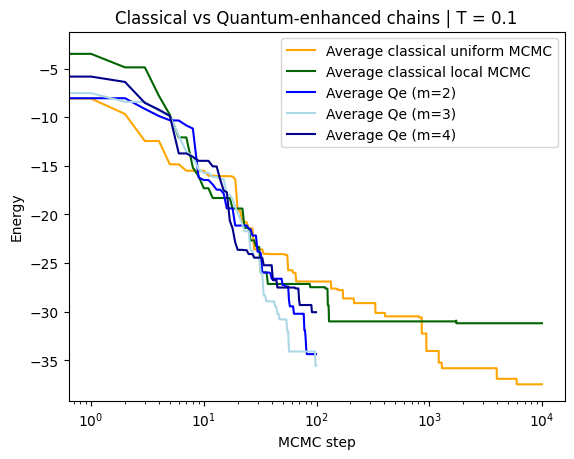

In [5]:
plot_chains(uni_chains, "orange", "classical uniform MCMC", plot_individual_chains=False)
plot_chains(loc_chains, "darkgreen", "classical local MCMC", plot_individual_chains=False)
colors = ["blue", "lightblue", "darkblue"]
for c, m, qe_chains in zip(colors, m_s, qe_chains_list):
    plot_chains(qe_chains, c, "Qe (m={})".format(m), plot_individual_chains=False)


plt.xlabel("MCMC step")
plt.ylabel("Energy")
plt.title("Classical vs Quantum-enhanced chains | T = {}".format(temp))
plt.legend()
plt.xscale("log")
plt.show()